# IFN680 Project 3 - Aircraft Classification

This notebook reproduces the learning curves, validation metrics and final
test-set evaluation used in the project report.

All training and model development were performed in `development.ipynb`.
This notebook loads the saved experimental results for reproducible reporting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
baseline = np.load("baseline_history.npz")
experiment1 = np.load("experiment1_history.npz")
experiment2 = np.load("experiment2_history.npz")
experiment3 = np.load("experiment3_history.npz")

final_history = np.load("final_model_history.npz")
test_results = np.load("winning_model_test_results.npz")

print("All saved results loaded successfully.")

All saved results loaded successfully.


In [9]:
# Baseline
baseline_train_loss = baseline["train_loss"]
baseline_val_loss = baseline["val_loss"]
baseline_train_acc = baseline["train_acc"]
baseline_val_acc = baseline["val_acc"]

# Experiment 1
experiment1_train_loss = experiment1["train_loss"]
experiment1_val_loss = experiment1["val_loss"]
experiment1_train_acc = experiment1["train_acc"]
experiment1_val_acc = experiment1["val_acc"]

# Experiment 2
experiment2_train_loss = experiment2["train_loss"]
experiment2_val_loss = experiment2["val_loss"]
experiment2_train_acc = experiment2["train_acc"]
experiment2_val_acc = experiment2["val_acc"]

# Experiment 3
experiment3_train_loss = experiment3["train_loss"]
experiment3_val_loss = experiment3["val_loss"]
experiment3_train_acc = experiment3["train_acc"]
experiment3_val_acc = experiment3["val_acc"]

# Final model retraining
final_train_loss = final_history["train_loss"]
final_train_acc = final_history["train_acc"]

# Final test results
class_accuracies = test_results["class_accuracies"]

average_per_class_accuracy = float(
    test_results["average_per_class_accuracy"]
)

all_predictions = test_results["predictions"]
all_labels = test_results["labels"]

print("Saved values extracted successfully.")

Saved values extracted successfully.


In [10]:
print(
    f"Baseline best validation accuracy: "
    f"{np.max(baseline_val_acc):.3f}"
)

print(
    f"Experiment 1 best validation accuracy: "
    f"{np.max(experiment1_val_acc):.3f}"
)

print(
    f"Experiment 2 best validation accuracy: "
    f"{np.max(experiment2_val_acc):.3f}"
)

print(
    f"Experiment 3 best validation accuracy: "
    f"{np.max(experiment3_val_acc):.3f}"
)

print()

print(
    f"Final average per-class test accuracy: "
    f"{average_per_class_accuracy:.3f}"
)

Baseline best validation accuracy: 0.805
Experiment 1 best validation accuracy: 0.850
Experiment 2 best validation accuracy: 0.835
Experiment 3 best validation accuracy: 0.794

Final average per-class test accuracy: 0.873


## Learning Curve Comparison

The validation accuracy of the baseline and three controlled experiments is
compared below. The additional full fine-tuning refinement is also included
because it was used to select the final winning model.

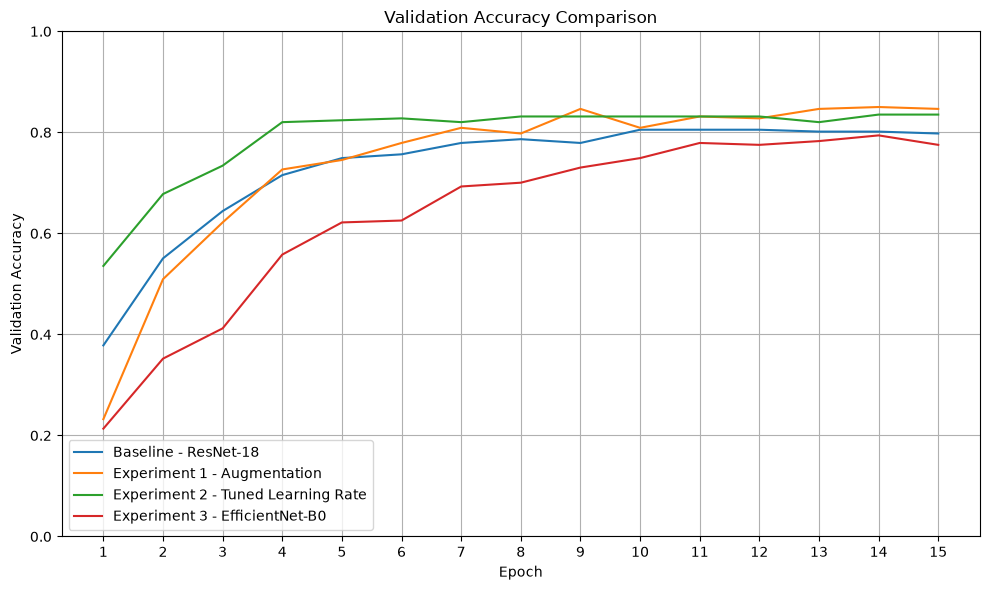

In [6]:
epochs = np.arange(1, len(baseline_val_acc) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_val_acc,
    label='Baseline - ResNet-18'
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label='Experiment 1 - Augmentation'
)

plt.plot(
    epochs,
    experiment2_val_acc,
    label='Experiment 2 - Tuned Learning Rate'
)

plt.plot(
    epochs,
    experiment3_val_acc,
    label='Experiment 3 - EfficientNet-B0'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
results_table = pd.DataFrame({
    "Model": [
        "Baseline - ResNet-18",
        "Experiment 1 - Augmentation",
        "Experiment 2 - Tuned Learning Rate",
        "Experiment 3 - EfficientNet-B0"
    ],
    "Best Validation Accuracy": [
        np.max(baseline_val_acc),
        np.max(experiment1_val_acc),
        np.max(experiment2_val_acc),
        np.max(experiment3_val_acc)
    ]
})

results_table

,Model,Best Validation Accuracy
0,Baseline - ResNet-18,0.805243
1,Experiment 1 - Augmentation,0.850187
2,Experiment 2 - Tuned Learning Rate,0.835206
3,Experiment 3 - EfficientNet-B0,0.794007


In [12]:
best_validation_accuracies = [
    np.max(baseline_val_acc),
    np.max(experiment1_val_acc),
    np.max(experiment2_val_acc),
    np.max(experiment3_val_acc)
]

model_names = [
    "Baseline - ResNet-18",
    "Experiment 1 - Augmentation",
    "Experiment 2 - Tuned Learning Rate",
    "Experiment 3 - EfficientNet-B0"
]

best_index = np.argmax(
    best_validation_accuracies
)

print(
    f"Best validation configuration: "
    f"{model_names[best_index]}"
)

print(
    f"Best validation accuracy: "
    f"{best_validation_accuracies[best_index]:.3f}"
)

Best validation configuration: Experiment 1 - Augmentation
Best validation accuracy: 0.850


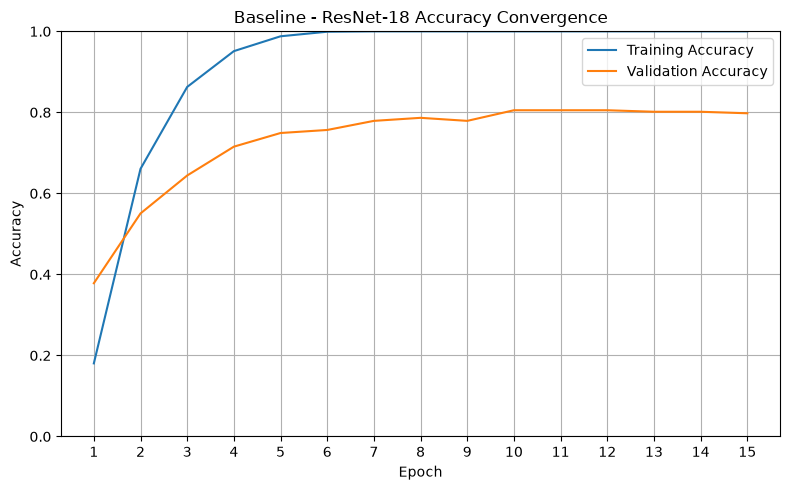

In [19]:
epochs = np.arange(1, len(baseline_train_acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    baseline_train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    baseline_val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline - ResNet-18 Accuracy Convergence")
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

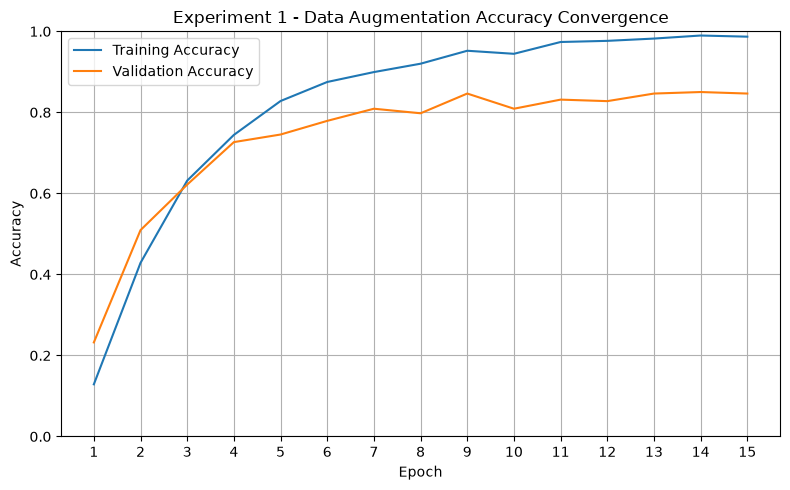

In [13]:
epochs = np.arange(
    1,
    len(experiment1_train_acc) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment1_train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Experiment 1 - Data Augmentation Accuracy Convergence"
)
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

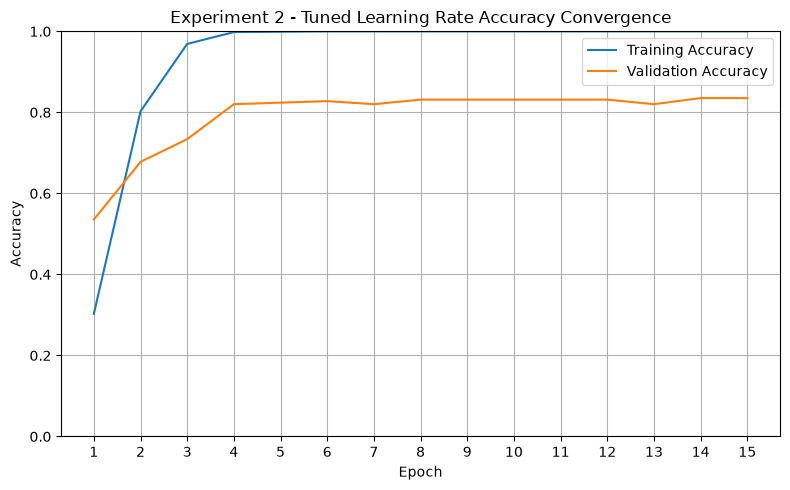

In [20]:
epochs = np.arange(1, len(experiment2_train_acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment2_train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    experiment2_val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 2 - Tuned Learning Rate Accuracy Convergence")
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

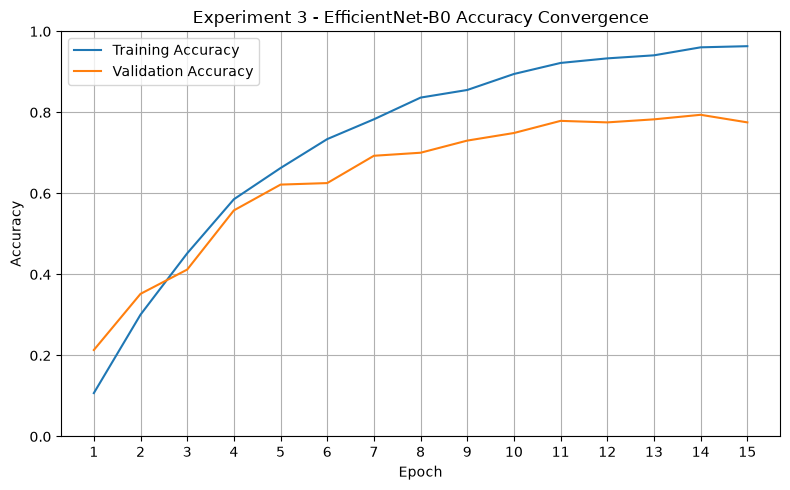

In [21]:
epochs = np.arange(1, len(experiment3_train_acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment3_train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    experiment3_val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 3 - EfficientNet-B0 Accuracy Convergence")
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

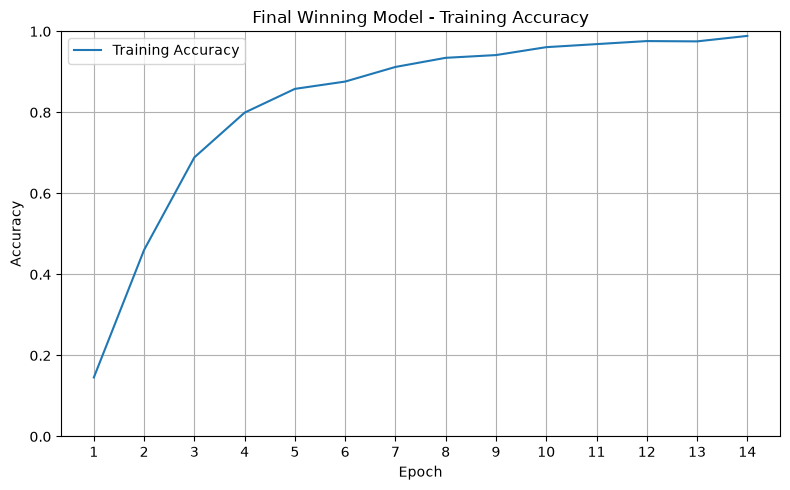

In [14]:
final_epochs = np.arange(
    1,
    len(final_train_acc) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    final_epochs,
    final_train_acc,
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Final Winning Model - Training Accuracy"
)
plt.xticks(final_epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
print(
    f"Final winning model average per-class "
    f"test accuracy: {average_per_class_accuracy:.3f}"
)

Final winning model average per-class test accuracy: 0.873


In [16]:
class_names = [
    f"class_{i:02d}"
    for i in range(20)
]

per_class_table = pd.DataFrame({
    "Aircraft Class": class_names,
    "Test Accuracy": class_accuracies
})

per_class_table

,Aircraft Class,Test Accuracy
0,class_00,0.500000
1,class_01,0.757576
2,class_02,0.878788
3,class_03,0.911765
4,class_04,0.941176
5,class_05,0.757576
6,class_06,0.911765
7,class_07,0.909091
8,class_08,0.823529
9,class_09,0.939394


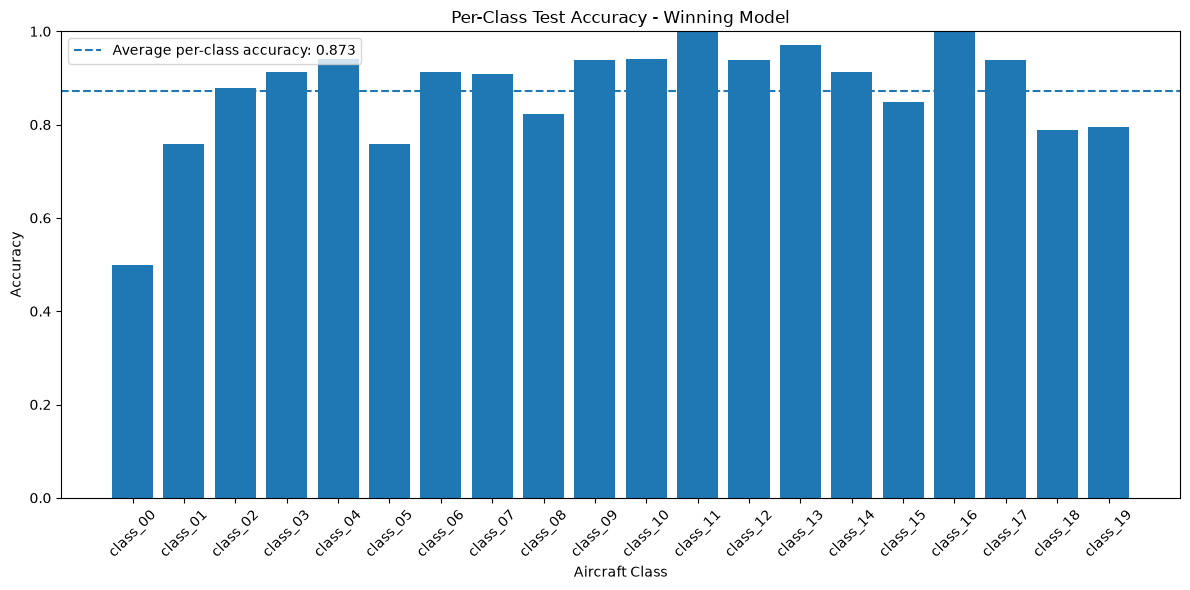

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    class_accuracies
)

plt.axhline(
    y=average_per_class_accuracy,
    linestyle="--",
    label=(
        f"Average per-class accuracy: "
        f"{average_per_class_accuracy:.3f}"
    )
)

plt.xlabel("Aircraft Class")
plt.ylabel("Accuracy")
plt.title(
    "Per-Class Test Accuracy - Winning Model"
)

plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.show()

In [18]:
sorted_classes = per_class_table.sort_values(
    by="Test Accuracy",
    ascending=False
)

print("Highest-performing classes:")
display(sorted_classes.head(3))

print("Lowest-performing classes:")
display(sorted_classes.tail(3))

Highest-performing classes:


,Aircraft Class,Test Accuracy
16,class_16,1.000000
11,class_11,1.000000
13,class_13,0.969697


Lowest-performing classes:


,Aircraft Class,Test Accuracy
1,class_01,0.757576
5,class_05,0.757576
0,class_00,0.500000
